# Import

In [1]:
from pathlib import Path
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Configure device

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Using device: cpu
Running on CPU


# Load shared vocabulary and sequence data

Loads directly from `data/shared/vocabulary.pkl` and `data/shared/sequence_data.npz` (produced once by `vocab.ipynb`) instead of rebuilding the vocab locally.

In [3]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = DATA_DIR / "shared"

with open(SHARED_DIR / "vocabulary.pkl", "rb") as file:
    vocab = pickle.load(file)

word_to_idx = vocab["word_to_idx"]
MAX_LENGTH = vocab["MAX_LENGTH"]

sequence_data = np.load(SHARED_DIR / "sequence_data.npz", allow_pickle=True)

train_padded = sequence_data["train_padded"]
val_padded = sequence_data["val_padded"]
test_padded = sequence_data["test_padded"]

train_lengths = sequence_data["train_lengths"]
val_lengths = sequence_data["val_lengths"]
test_lengths = sequence_data["test_lengths"]

y_train = sequence_data["y_train"]
y_val = sequence_data["y_val"]
y_test = sequence_data["y_test"]

# Raw text, aligned row-for-row with the arrays above -- needed for TF-IDF/Word2Vec
# and error analysis. Reading it straight from the shared file instead of re-reading
# train_processed.csv and re-doing the split avoids relying on split-determinism.
train_texts = sequence_data["train_texts"]
val_texts = sequence_data["val_texts"]
test_texts = sequence_data["test_texts"]

print(f"Vocabulary size: {len(word_to_idx):,}")
print(f"MAX_LENGTH: {MAX_LENGTH}")
print("Train padded:", train_padded.shape)
print("Val padded:", val_padded.shape)
print("Test padded:", test_padded.shape)

Vocabulary size: 60,725
MAX_LENGTH: 321
Train padded: (19923, 321)
Val padded: (4981, 321)
Test padded: (24801, 321)


# PyTorch Dataset and DataLoaders

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )


train_dataset = ReviewDataset(train_padded, train_lengths, y_train)
val_dataset = ReviewDataset(val_padded, val_lengths, y_val)
test_dataset = ReviewDataset(test_padded, test_lengths, y_test)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=device.type == "cuda"
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=device.type == "cuda"
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=device.type == "cuda"
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

sequences_batch, lengths_batch, labels_batch = next(iter(train_loader))
print("Sequences shape:", sequences_batch.shape)
print("Lengths shape:", lengths_batch.shape)
print("Labels shape:", labels_batch.shape)

Training batches: 623
Validation batches: 156
Testing batches: 776
Sequences shape: torch.Size([32, 321])
Lengths shape: torch.Size([32])
Labels shape: torch.Size([32])


# Embeddings

## Word2Vec

In [5]:
from gensim.models import Word2Vec
import time

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

WORD2VEC_PATH = SHARED_DIR / "models" / "word2vec_imdb.model"
word2vec_model = Word2Vec.load(str(WORD2VEC_PATH))

print("Word2Vec model loaded from:", WORD2VEC_PATH)
print("Vector size:", word2vec_model.vector_size)
print("Vocabulary size:", len(word2vec_model.wv))

Word2Vec model loaded from: c:\Users\Johny\Desktop\inmind\Assignment4\Assignment4_NLP_SequenceModels\data\shared\models\word2vec_imdb.model
Vector size: 100
Vocabulary size: 37953


In [6]:
word2vec_vectors = word2vec_model.wv
WORD2VEC_DIM = word2vec_vectors.vector_size

rng = np.random.default_rng(SEED)

word2vec_embedding_matrix = rng.normal(
    loc=0.0, scale=0.05, size=(len(word_to_idx), WORD2VEC_DIM)
).astype(np.float32)

word2vec_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0
for word, idx in word_to_idx.items():
    if word in word2vec_vectors:
        word2vec_embedding_matrix[idx] = word2vec_vectors[word]
        matched_words += 1

word2vec_coverage = matched_words / len(word_to_idx) * 100

print("Word2Vec matrix shape:", word2vec_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {word2vec_coverage:.2f}%")

np.save(MODELS_DIR / "word2vec_embedding_matrix.npy", word2vec_embedding_matrix)
print("Word2Vec embedding matrix saved.")

Word2Vec matrix shape: (60725, 100)
Matched words: 37953
Vocabulary coverage: 62.50%
Word2Vec embedding matrix saved.


## GloVe

In [7]:
import gensim.downloader as api

start_time = time.time()

print("Loading pretrained GloVe...")
glove_model = api.load("glove-wiki-gigaword-100")

elapsed_time = time.time() - start_time

print("GloVe loaded successfully.")
print("Vector size:", glove_model.vector_size)
print(f"Loading time: {elapsed_time / 60:.2f} minutes")

Loading pretrained GloVe...
GloVe loaded successfully.
Vector size: 100
Loading time: 0.67 minutes


In [8]:
GLOVE_DIM = glove_model.vector_size

rng = np.random.default_rng(SEED)

glove_embedding_matrix = rng.normal(
    loc=0.0, scale=0.05, size=(len(word_to_idx), GLOVE_DIM)
).astype(np.float32)

glove_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0
for word, idx in word_to_idx.items():
    if word in glove_model:
        glove_embedding_matrix[idx] = glove_model[word]
        matched_words += 1

glove_coverage = matched_words / len(word_to_idx) * 100

print("GloVe matrix shape:", glove_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {glove_coverage:.2f}%")

np.save(MODELS_DIR / "glove_embedding_matrix.npy", glove_embedding_matrix)
print("GloVe embedding matrix saved.")

GloVe matrix shape: (60725, 100)
Matched words: 49464
Vocabulary coverage: 81.46%
GloVe embedding matrix saved.


## TF-IDF

In [9]:
from scipy.sparse import load_npz

TFIDF_DIR = SHARED_DIR / "tfidf"

with open(TFIDF_DIR / "tfidf_vectorizer.pkl", "rb") as file:
    tfidf_vectorizer = pickle.load(file)

X_train_tfidf = load_npz(TFIDF_DIR / "X_train_tfidf.npz")
X_val_tfidf = load_npz(TFIDF_DIR / "X_val_tfidf.npz")
X_test_tfidf = load_npz(TFIDF_DIR / "X_test_tfidf.npz")

print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)
print("TF-IDF vocabulary size:", len(tfidf_vectorizer.vocabulary_))

c:\Users\Johny\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Johny\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Train: (19923, 20000)
Validation: (4981, 20000)
Test: (24801, 20000)
TF-IDF vocabulary size: 20000


# RNN Model

In [10]:
from torch.nn.utils.rnn import pack_padded_sequence


class RNNClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32
        )

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embeddings,
            padding_idx=word_to_idx["<PAD>"]
        )

        embedding_dim = embedding_matrix.shape[1]

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, sequences, lengths):
        embedded = self.embedding(sequences)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)

        logits = self.output(final_hidden).squeeze(1)

        return logits

# Training functions

In [11]:
import time
import copy

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for sequences, lengths, labels in data_loader:
        sequences = sequences.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(sequences, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        # Helps reduce exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item() * labels.size(0)
        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy



def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(sequences, lengths)
            loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    model_path
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_model_state,
                model_path
            )

            print("Best model saved.")

    elapsed_time = time.time() - start_time

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(
        f"\nTraining completed in "
        f"{elapsed_time / 60:.2f} minutes."
    )

    return history

# Evaluation functions

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


def evaluate_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)

            logits = model(sequences, lengths)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            all_labels.extend(labels.numpy().astype(int))
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    metrics = {
        "accuracy": accuracy_score(all_labels, all_predictions),
        "precision": precision_score(all_labels, all_predictions, zero_division=0),
        "recall": recall_score(all_labels, all_predictions, zero_division=0),
        "f1": f1_score(all_labels, all_predictions, zero_division=0)
    }

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )


def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_accuracy"], label="Training Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()

# Experiments

In [13]:
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 5

## Frozen GloVe RNN

In [14]:
glove_frozen_model = RNNClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(lambda parameter: parameter.requires_grad, glove_frozen_model.parameters()),
    lr=LEARNING_RATE
)

print("Training Frozen GloVe RNN...")
print("Device:", device)

glove_frozen_history = train_model(
    model=glove_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_glove_frozen.pt"
)

Training Frozen GloVe RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.5923 | Train Accuracy: 0.6890 | Val Loss: 0.5895 | Val Accuracy: 0.7017
Best model saved.
Epoch 02/5 | Train Loss: 0.5512 | Train Accuracy: 0.7324 | Val Loss: 0.5462 | Val Accuracy: 0.7412
Best model saved.
Epoch 03/5 | Train Loss: 0.5457 | Train Accuracy: 0.7370 | Val Loss: 0.5619 | Val Accuracy: 0.7406
Epoch 04/5 | Train Loss: 0.5411 | Train Accuracy: 0.7393 | Val Loss: 0.5387 | Val Accuracy: 0.7416
Best model saved.
Epoch 05/5 | Train Loss: 0.5664 | Train Accuracy: 0.7224 | Val Loss: 0.6580 | Val Accuracy: 0.6240

Training completed in 3.71 minutes.


In [15]:
(
    glove_frozen_metrics,
    glove_frozen_labels,
    glove_frozen_predictions,
    glove_frozen_probabilities
) = evaluate_model(glove_frozen_model, test_loader, device)

print(glove_frozen_metrics)
print(classification_report(
    glove_frozen_labels, glove_frozen_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(glove_frozen_labels, glove_frozen_predictions))

{'accuracy': 0.7469053667190839, 'precision': 0.8317364624825062, 'recall': 0.6210610932475884, 'f1': 0.7111233834967094}
              precision    recall  f1-score   support

    Negative       0.70      0.87      0.77     12361
    Positive       0.83      0.62      0.71     12440

    accuracy                           0.75     24801
   macro avg       0.76      0.75      0.74     24801
weighted avg       0.76      0.75      0.74     24801

[[10798  1563]
 [ 4714  7726]]


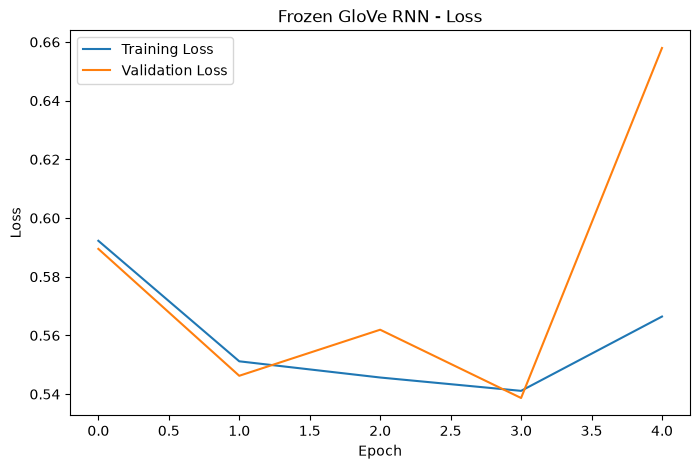

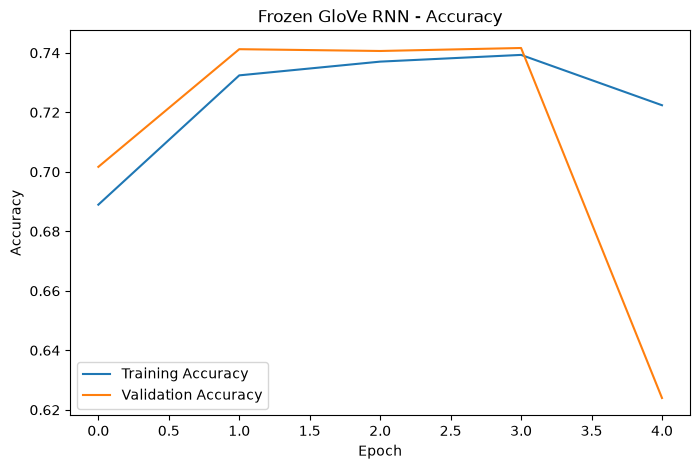

In [16]:
plot_training_history(glove_frozen_history, "Frozen GloVe RNN")

In [17]:
import gc

del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine-tuned GloVe RNN

In [18]:
glove_finetuned_model = RNNClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(glove_finetuned_model.parameters(), lr=LEARNING_RATE)

print("Training Fine-Tuned GloVe RNN...")
print("Device:", device)

glove_finetuned_history = train_model(
    model=glove_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_glove_finetuned.pt"
)

Training Fine-Tuned GloVe RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.5325 | Train Accuracy: 0.7437 | Val Loss: 0.4632 | Val Accuracy: 0.8000
Best model saved.
Epoch 02/5 | Train Loss: 0.4024 | Train Accuracy: 0.8321 | Val Loss: 0.4569 | Val Accuracy: 0.8057
Best model saved.
Epoch 03/5 | Train Loss: 0.3163 | Train Accuracy: 0.8743 | Val Loss: 0.5899 | Val Accuracy: 0.7456
Epoch 04/5 | Train Loss: 0.2669 | Train Accuracy: 0.8981 | Val Loss: 0.4517 | Val Accuracy: 0.7994
Best model saved.
Epoch 05/5 | Train Loss: 0.2287 | Train Accuracy: 0.9175 | Val Loss: 0.4656 | Val Accuracy: 0.8287

Training completed in 5.39 minutes.


In [19]:
(
    glove_finetuned_metrics,
    glove_finetuned_labels,
    glove_finetuned_predictions,
    glove_finetuned_probabilities
) = evaluate_model(glove_finetuned_model, test_loader, device)

print(glove_finetuned_metrics)
print(classification_report(
    glove_finetuned_labels, glove_finetuned_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(glove_finetuned_labels, glove_finetuned_predictions))

{'accuracy': 0.7956130801177372, 'precision': 0.7772094772470853, 'recall': 0.8306270096463022, 'f1': 0.8030308917816203}
              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79     12361
    Positive       0.78      0.83      0.80     12440

    accuracy                           0.80     24801
   macro avg       0.80      0.80      0.80     24801
weighted avg       0.80      0.80      0.80     24801

[[ 9399  2962]
 [ 2107 10333]]


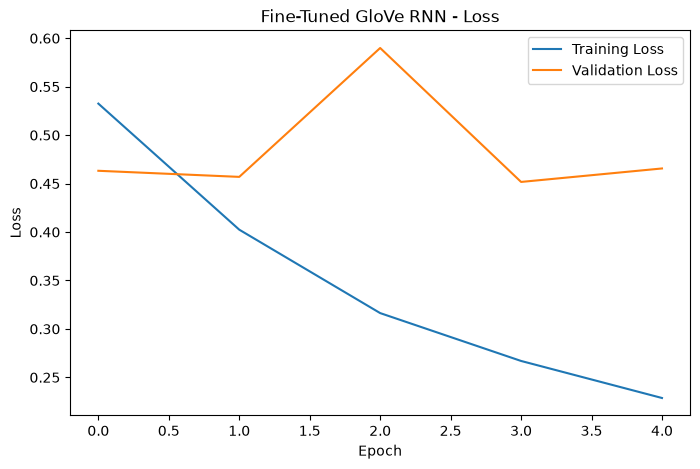

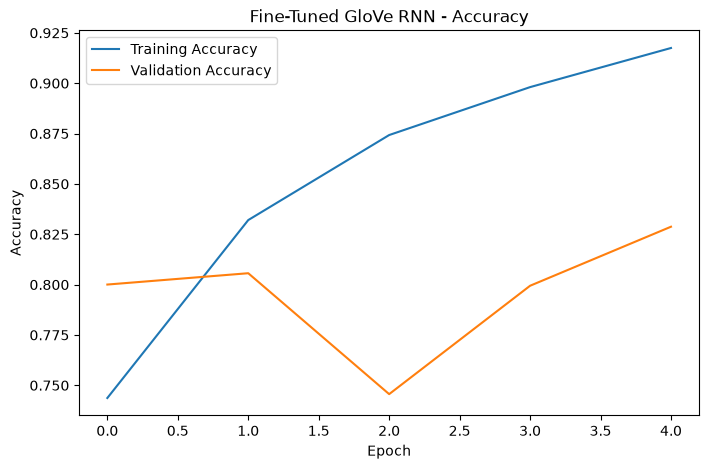

In [20]:
plot_training_history(glove_finetuned_history, "Fine-Tuned GloVe RNN")

In [21]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Frozen Word2Vec RNN

In [22]:
word2vec_frozen_model = RNNClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(lambda parameter: parameter.requires_grad, word2vec_frozen_model.parameters()),
    lr=LEARNING_RATE
)

print("Training Frozen Word2Vec RNN...")
print("Device:", device)

word2vec_frozen_history = train_model(
    model=word2vec_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_word2vec_frozen.pt"
)

Training Frozen Word2Vec RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.4705 | Train Accuracy: 0.7884 | Val Loss: 0.4049 | Val Accuracy: 0.8287
Best model saved.
Epoch 02/5 | Train Loss: 0.4271 | Train Accuracy: 0.8223 | Val Loss: 0.4105 | Val Accuracy: 0.8235
Epoch 03/5 | Train Loss: 0.4273 | Train Accuracy: 0.8223 | Val Loss: 0.4445 | Val Accuracy: 0.8081
Epoch 04/5 | Train Loss: 0.4152 | Train Accuracy: 0.8303 | Val Loss: 0.4146 | Val Accuracy: 0.8259
Epoch 05/5 | Train Loss: 0.4168 | Train Accuracy: 0.8278 | Val Loss: 0.4065 | Val Accuracy: 0.8298

Training completed in 3.88 minutes.


In [23]:
(
    word2vec_frozen_metrics,
    word2vec_frozen_labels,
    word2vec_frozen_predictions,
    word2vec_frozen_probabilities
) = evaluate_model(word2vec_frozen_model, test_loader, device)

print(word2vec_frozen_metrics)
print(classification_report(
    word2vec_frozen_labels, word2vec_frozen_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(word2vec_frozen_labels, word2vec_frozen_predictions))

{'accuracy': 0.8200878996814644, 'precision': 0.8605386840202458, 'recall': 0.7653536977491961, 'f1': 0.8101599727705923}
              precision    recall  f1-score   support

    Negative       0.79      0.88      0.83     12361
    Positive       0.86      0.77      0.81     12440

    accuracy                           0.82     24801
   macro avg       0.82      0.82      0.82     24801
weighted avg       0.82      0.82      0.82     24801

[[10818  1543]
 [ 2919  9521]]


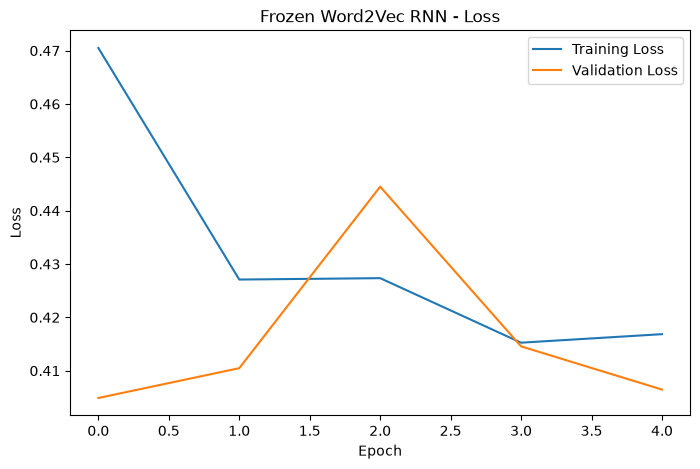

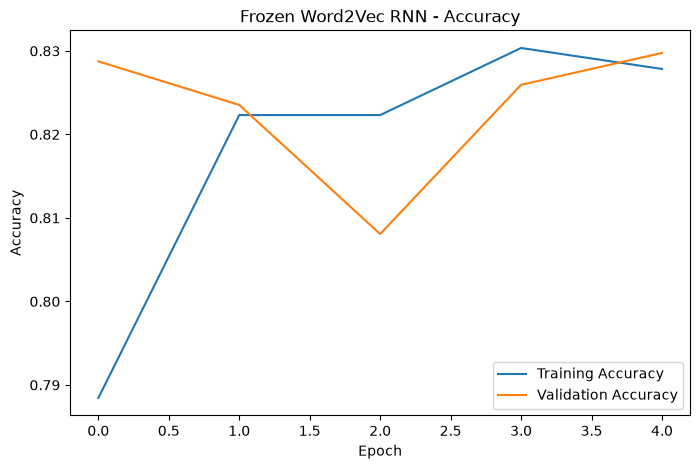

In [24]:
plot_training_history(word2vec_frozen_history, "Frozen Word2Vec RNN")

In [25]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine-tuned Word2Vec RNN

In [26]:
word2vec_finetuned_model = RNNClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(word2vec_finetuned_model.parameters(), lr=LEARNING_RATE)

print("Training Fine-Tuned Word2Vec RNN...")
print("Device:", device)

word2vec_finetuned_history = train_model(
    model=word2vec_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_word2vec_finetuned.pt"
)

Training Fine-Tuned Word2Vec RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.4454 | Train Accuracy: 0.8077 | Val Loss: 0.4335 | Val Accuracy: 0.8127
Best model saved.
Epoch 02/5 | Train Loss: 0.3394 | Train Accuracy: 0.8648 | Val Loss: 0.4263 | Val Accuracy: 0.8147
Best model saved.
Epoch 03/5 | Train Loss: 0.2615 | Train Accuracy: 0.9054 | Val Loss: 0.4114 | Val Accuracy: 0.8384
Best model saved.
Epoch 04/5 | Train Loss: 0.1971 | Train Accuracy: 0.9275 | Val Loss: 0.4842 | Val Accuracy: 0.8378
Epoch 05/5 | Train Loss: 0.1412 | Train Accuracy: 0.9511 | Val Loss: 0.5657 | Val Accuracy: 0.8143

Training completed in 5.45 minutes.


In [27]:
(
    word2vec_finetuned_metrics,
    word2vec_finetuned_labels,
    word2vec_finetuned_predictions,
    word2vec_finetuned_probabilities
) = evaluate_model(word2vec_finetuned_model, test_loader, device)

print(word2vec_finetuned_metrics)
print(classification_report(
    word2vec_finetuned_labels, word2vec_finetuned_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(word2vec_finetuned_labels, word2vec_finetuned_predictions))

{'accuracy': 0.8289988306923108, 'precision': 0.7931355023239185, 'recall': 0.8916398713826367, 'f1': 0.8395080416272469}
              precision    recall  f1-score   support

    Negative       0.88      0.77      0.82     12361
    Positive       0.79      0.89      0.84     12440

    accuracy                           0.83     24801
   macro avg       0.83      0.83      0.83     24801
weighted avg       0.83      0.83      0.83     24801

[[ 9468  2893]
 [ 1348 11092]]


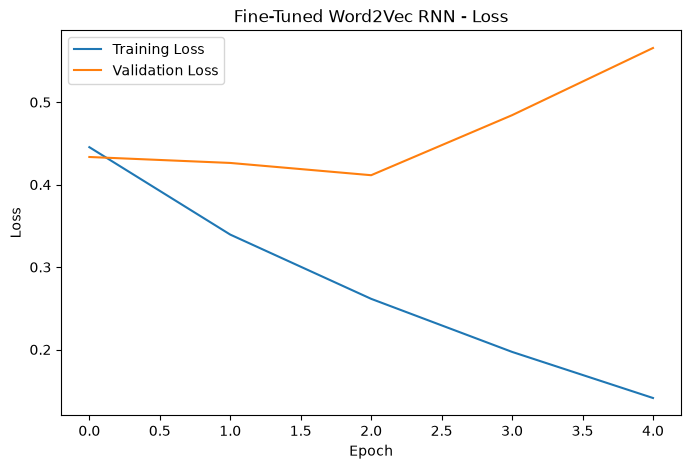

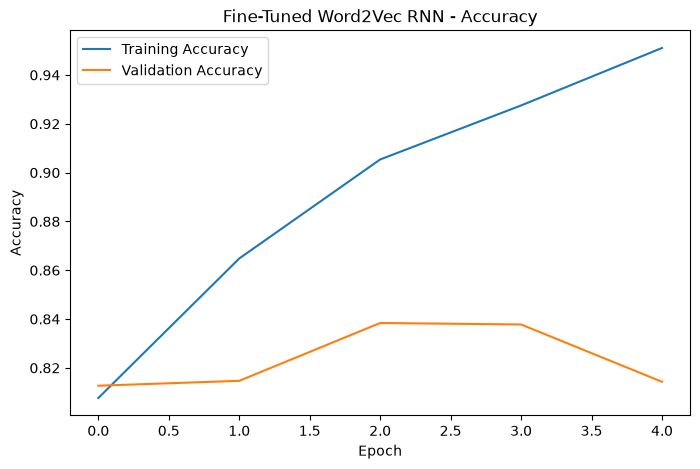

In [28]:
plot_training_history(word2vec_finetuned_history, "Fine-Tuned Word2Vec RNN")

# TF-IDF RNN

## Dataset and DataLoaders

In [29]:
class TfidfDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features  # sparse matrix, kept sparse until __getitem__
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        # Only densify the one row we need, not the whole matrix
        feature = self.features[index].toarray().squeeze()
        return (
            torch.tensor(feature, dtype=torch.float32),
            torch.tensor(self.labels[index], dtype=torch.float32)
        )


tfidf_train_dataset = TfidfDataset(X_train_tfidf, y_train)
tfidf_val_dataset = TfidfDataset(X_val_tfidf, y_val)
tfidf_test_dataset = TfidfDataset(X_test_tfidf, y_test)

tfidf_train_loader = DataLoader(
    tfidf_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=device.type == "cuda"
)
tfidf_val_loader = DataLoader(
    tfidf_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=device.type == "cuda"
)
tfidf_test_loader = DataLoader(
    tfidf_test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=device.type == "cuda"
)

features_batch, labels_batch = next(iter(tfidf_train_loader))
print("Features shape:", features_batch.shape)
print("Labels shape:", labels_batch.shape)

Features shape: torch.Size([32, 20000])
Labels shape: torch.Size([32])


## TF-IDF RNN Model

In [30]:
class TfidfRNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1, dropout=0.3):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, features):
        # [batch, features] -> [batch, 1, features] -- one "timestep"
        features = features.unsqueeze(1)

        _, hidden = self.rnn(features)

        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)

        logits = self.output(final_hidden).squeeze(1)

        return logits

## Training and evaluation functions

In [31]:
def train_tfidf_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for features, labels in data_loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(features)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item() * labels.size(0)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy


def validate_tfidf_one_epoch(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(features)
            loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy


def train_tfidf_model(
    model, train_loader, val_loader, criterion, optimizer,
    device, epochs, model_path
):
    history = {
        "train_loss": [], "val_loss": [],
        "train_accuracy": [], "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_tfidf_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_accuracy = validate_tfidf_one_epoch(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, model_path)
            print("Best model saved.")

    elapsed_time = time.time() - start_time

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\nTraining completed in {elapsed_time / 60:.2f} minutes.")

    return history


def evaluate_tfidf_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device, non_blocking=True)

            logits = model(features)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            all_labels.extend(labels.numpy().astype(int))
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    metrics = {
        "accuracy": accuracy_score(all_labels, all_predictions),
        "precision": precision_score(all_labels, all_predictions, zero_division=0),
        "recall": recall_score(all_labels, all_predictions, zero_division=0),
        "f1": f1_score(all_labels, all_predictions, zero_division=0)
    }

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

## Run TF-IDF RNN

In [32]:
TFIDF_INPUT_SIZE = X_train_tfidf.shape[1]

tfidf_model = TfidfRNNClassifier(
    input_size=TFIDF_INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(tfidf_model.parameters(), lr=LEARNING_RATE)

print("Training TF-IDF RNN...")
print("Device:", device)

tfidf_history = train_tfidf_model(
    model=tfidf_model,
    train_loader=tfidf_train_loader,
    val_loader=tfidf_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_tfidf.pt"
)

Training TF-IDF RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.3704 | Train Accuracy: 0.8542 | Val Loss: 0.2555 | Val Accuracy: 0.8966
Best model saved.
Epoch 02/5 | Train Loss: 0.1552 | Train Accuracy: 0.9470 | Val Loss: 0.2646 | Val Accuracy: 0.8904
Epoch 03/5 | Train Loss: 0.0856 | Train Accuracy: 0.9738 | Val Loss: 0.3132 | Val Accuracy: 0.8834
Epoch 04/5 | Train Loss: 0.0446 | Train Accuracy: 0.9900 | Val Loss: 0.3797 | Val Accuracy: 0.8757
Epoch 05/5 | Train Loss: 0.0216 | Train Accuracy: 0.9965 | Val Loss: 0.4398 | Val Accuracy: 0.8727

Training completed in 0.85 minutes.


In [33]:
(
    tfidf_metrics,
    tfidf_labels,
    tfidf_predictions,
    tfidf_probabilities
) = evaluate_tfidf_model(tfidf_model, tfidf_test_loader, device)

print(tfidf_metrics)
print(classification_report(
    tfidf_labels, tfidf_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(tfidf_labels, tfidf_predictions))

{'accuracy': 0.8827869843957905, 'precision': 0.8719469371829887, 'recall': 0.8982315112540193, 'f1': 0.8848940803801227}
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88     12361
    Positive       0.87      0.90      0.88     12440

    accuracy                           0.88     24801
   macro avg       0.88      0.88      0.88     24801
weighted avg       0.88      0.88      0.88     24801

[[10720  1641]
 [ 1266 11174]]


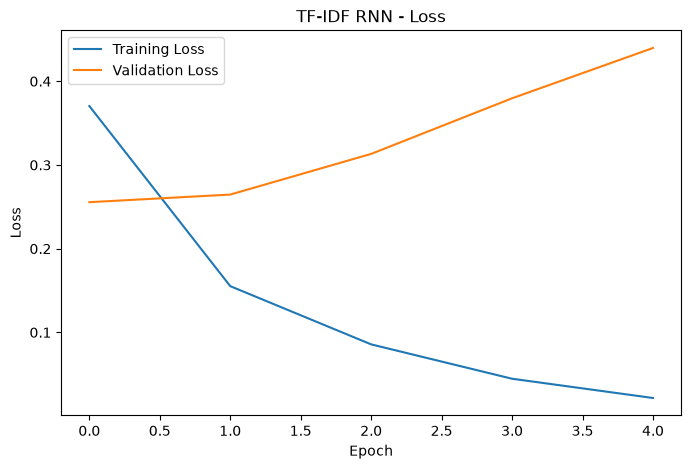

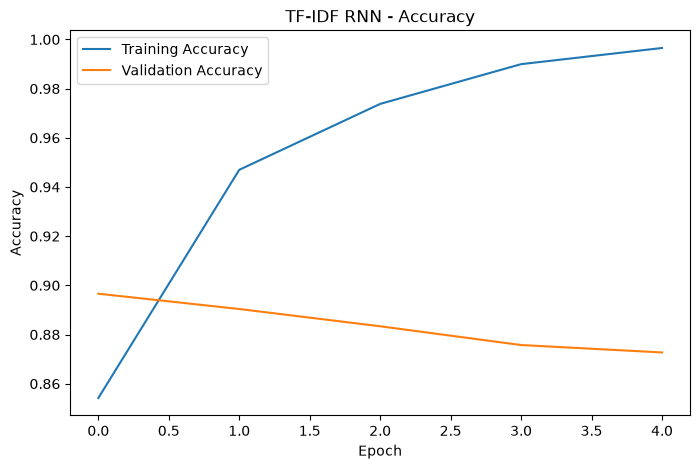

In [34]:
plot_training_history(tfidf_history, "TF-IDF RNN")

In [35]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Results Comparison

In [36]:
results = [
    {"Model": "RNN", "Embedding": "GloVe", "Variant": "Frozen", **glove_frozen_metrics},
    {"Model": "RNN", "Embedding": "GloVe", "Variant": "Fine-Tuned", **glove_finetuned_metrics},
    {"Model": "RNN", "Embedding": "Word2Vec", "Variant": "Frozen", **word2vec_frozen_metrics},
    {"Model": "RNN", "Embedding": "Word2Vec", "Variant": "Fine-Tuned", **word2vec_finetuned_metrics},
    {"Model": "RNN", "Embedding": "TF-IDF", "Variant": "N/A", **tfidf_metrics},
]

results_df = pd.DataFrame(results)
results_df

,Model,Embedding,Variant,accuracy,precision,recall,f1
0,RNN,GloVe,Frozen,0.746905,0.831736,0.621061,0.711123
1,RNN,GloVe,Fine-Tuned,0.795613,0.777209,0.830627,0.803031
2,RNN,Word2Vec,Frozen,0.820088,0.860539,0.765354,0.810160
3,RNN,Word2Vec,Fine-Tuned,0.828999,0.793136,0.891640,0.839508
4,RNN,TF-IDF,N/A,0.882787,0.871947,0.898232,0.884894


In [37]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_DIR / "rnn_results.csv", index=False)
print("Results saved.")

Results saved.


In [38]:
best_variant_row = results_df.loc[results_df["f1"].idxmax()]
print("Best RNN variant:")
print(best_variant_row)

Best RNN variant:
Model             RNN
Embedding      TF-IDF
Variant           N/A
accuracy     0.882787
precision    0.871947
recall       0.898232
f1           0.884894
Name: 4, dtype: object


# Error Analysis

Analyzing errors for best variant: TF-IDF (N/A)
F1: 0.8849
Total test samples: 24801
Misclassified: 2907 (11.72%)
False positives (predicted positive, actually negative): 1641
False negatives (predicted negative, actually positive): 1266

--- Sample False Positives ---
[length=142, confidence=0.713] brass picture movie not fitting word really somewhat brassy alluring visual quality reminiscent expensive high class tv commercial unfortunately brass picture feature film pretense wanting entertain v

[length=69, confidence=0.781] bottom end apocalypse movie scale piece pish called final executioner least come bloke trained ex cop seek vengeance killed woman friend cold blood lot fake explosion repetitive shooting ensue one wei

[length=117, confidence=0.687] earth destroyed nuclear holocaust well part earth somewhere italy band purebred survivor without radioactive contamination holed massive mansion surrounded lush ground waiting next opportunity go hunt

[length=48, confidence=0.636] ne

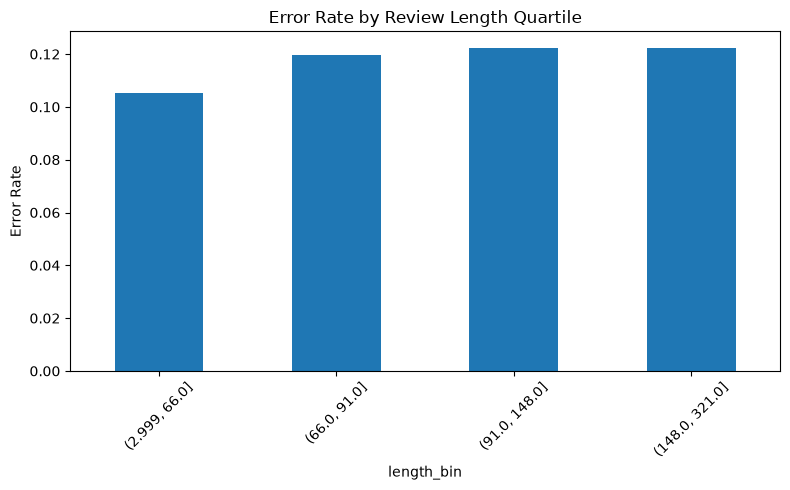

In [39]:
variant_results = {
    ("GloVe", "Frozen"): (glove_frozen_labels, glove_frozen_predictions, glove_frozen_probabilities),
    ("GloVe", "Fine-Tuned"): (glove_finetuned_labels, glove_finetuned_predictions, glove_finetuned_probabilities),
    ("Word2Vec", "Frozen"): (word2vec_frozen_labels, word2vec_frozen_predictions, word2vec_frozen_probabilities),
    ("Word2Vec", "Fine-Tuned"): (word2vec_finetuned_labels, word2vec_finetuned_predictions, word2vec_finetuned_probabilities),
    ("TF-IDF", "N/A"): (tfidf_labels, tfidf_predictions, tfidf_probabilities),
}

best_labels, best_predictions, best_probabilities = variant_results[
    (best_variant_row["Embedding"], best_variant_row["Variant"])
]

print(f"Analyzing errors for best variant: {best_variant_row['Embedding']} ({best_variant_row['Variant']})")
print(f"F1: {best_variant_row['f1']:.4f}")


def analyze_errors(labels, predictions, probabilities, texts, lengths, n_examples=5):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions).reshape(-1)
    probabilities = np.asarray(probabilities).reshape(-1)
    lengths = np.asarray(lengths)
    texts = np.asarray(texts)

    misclassified_mask = predictions != labels
    false_positive_mask = misclassified_mask & (predictions == 1)
    false_negative_mask = misclassified_mask & (predictions == 0)

    print(f"Total test samples: {len(labels)}")
    print(f"Misclassified: {misclassified_mask.sum()} ({misclassified_mask.mean() * 100:.2f}%)")
    print(f"False positives (predicted positive, actually negative): {false_positive_mask.sum()}")
    print(f"False negatives (predicted negative, actually positive): {false_negative_mask.sum()}")

    print("\n--- Sample False Positives ---")
    for idx in np.where(false_positive_mask)[0][:n_examples]:
        print(f"[length={lengths[idx]}, confidence={probabilities[idx]:.3f}] {texts[idx][:200]}")
        print()

    print("--- Sample False Negatives ---")
    for idx in np.where(false_negative_mask)[0][:n_examples]:
        print(f"[length={lengths[idx]}, confidence={probabilities[idx]:.3f}] {texts[idx][:200]}")
        print()

    length_bins = pd.qcut(lengths, q=4, duplicates="drop")
    error_by_length = pd.DataFrame({
        "length_bin": length_bins,
        "is_error": misclassified_mask
    }).groupby("length_bin", observed=True)["is_error"].mean()

    print("--- Error rate by review length quartile ---")
    print(error_by_length)

    plt.figure(figsize=(8, 5))
    error_by_length.plot(kind="bar")
    plt.ylabel("Error Rate")
    plt.title("Error Rate by Review Length Quartile")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return misclassified_mask, false_positive_mask, false_negative_mask


misclassified_mask, false_positive_mask, false_negative_mask = analyze_errors(
    best_labels, best_predictions, best_probabilities,
    test_texts, test_lengths
)

# Save Best Model

In [40]:
checkpoint_filenames = {
    ("GloVe", "Frozen"): "rnn_glove_frozen.pt",
    ("GloVe", "Fine-Tuned"): "rnn_glove_finetuned.pt",
    ("Word2Vec", "Frozen"): "rnn_word2vec_frozen.pt",
    ("Word2Vec", "Fine-Tuned"): "rnn_word2vec_finetuned.pt",
    ("TF-IDF", "N/A"): "rnn_tfidf.pt",
}

best_checkpoint_path = MODELS_DIR / checkpoint_filenames[
    (best_variant_row["Embedding"], best_variant_row["Variant"])
]

print("Best RNN variant:", best_variant_row["Embedding"], best_variant_row["Variant"])
print("Best checkpoint saved at:", best_checkpoint_path)

Best RNN variant: TF-IDF N/A
Best checkpoint saved at: models\rnn_tfidf.pt
